In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
#from lifelines.statistics import logrank_test, multivariate_logrank_test
import pandas as pd
from lifelines import KaplanMeierFitter

In [286]:
## PLOT THE SURVIVAL CURVES FOR EACH CLIENT MDS

features = ['Gender', 'AOD', 'Neutrophils', 'Hemoglobin', 'Platelets', 'BMB',
            'ASXL1', 'BCOR', 'BCORL1', 'CBL', 'CEBPA', 'DNMT3A', 'ETV6', 'EZH2',
            'FLT3', 'GATA2', 'GNAS', 'IDH1', 'IDH2', 'JAK2', 'KIT', 'KRAS', 'MPL',
            'NPM1', 'NRAS', 'PTPN11', 'RUNX1', 'SF3B1', 'SRSF2', 'STAG2', 'TET2',
            'TP53', 'U2AF1', 'WT1', 'ZRSR2', 'SETBP1', 'time', 'event']

cols_standardize = ['AOD', 'Neutrophils', 'Hemoglobin', 'Platelets', 'BMB']


g1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/MDS/SYNTH_UNBIASED.csv").sample(n=300,random_state=41).reset_index(drop=True)
g2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/MDS/SYNTH_UNBIASED.csv").sample(n=300,random_state=41).reset_index(drop=True).sample(n=300,random_state=42).reset_index(drop=True)
g3 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node3/MDS/SYNTH_UNBIASED.csv").sample(n=300,random_state=41).reset_index(drop=True)

s11 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node1/mds1_biased_denorm_mds1.csv").loc[:299]
s21 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node1/mds2_biased_denorm_mds1.csv").loc[:299]
s31 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node1/mds3_biased_denorm_mds1.csv").loc[:299]
S1 = pd.concat((s11, s21), axis = 0)
S1 = pd.concat((S1, s31), axis=0)
s12 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node2/mds1_biased_denorm_mds2.csv").loc[:299]
s22 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node2/mds2_biased_denorm_mds2.csv").loc[:299]
s32 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node2/mds3_biased_denorm_mds2.csv").loc[:299]
S2 = pd.concat((s12, s22), axis = 0)
S2 = pd.concat((S2, s32), axis=0)
s13 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node3/mds1_biased_denorm_mds3.csv").loc[:299]
s23 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node3/mds2_biased_denorm_mds3.csv").loc[:299]
s33 = pd.read_csv("C:/Users/Lenovo/Desktop/MDS_/FL/Node3/mds3_biased_denorm_mds3.csv").loc[:299]
S3 = pd.concat((s13, s23), axis = 0)
S3 = pd.concat((S3, s33), axis=0)

S1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/MDS/SYNTH_BIASED.csv").sample(n=900,random_state=41).reset_index(drop=True)
S2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/MDS/SYNTH_BIASED.csv").sample(n=900,random_state=41).reset_index(drop=True)
S3 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node3/MDS/SYNTH_BIASED.csv").sample(n=900,random_state=41).reset_index(drop=True)
r1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/MDS/mds_.csv")
r2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/MDS/mds_.csv")
r3 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node3/MDS/mds_.csv")
t1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/MDS/mdstest_.csv")
t2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/MDS/mdstest_.csv")
t3 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node3/MDS/mdstest_.csv")

r1.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]
r2.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]
r3.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]
t1.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]
t2.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]
t3.rename(columns={'OverallSurvival': 'time', 'DeadOrAliveAtTransplantation': 'event', }, inplace=True)  # [features]

r1 = r1[features]
r2 = r2[features]
r3 = r3[features]
t1 = t1[features]
t2 = t2[features]
t3 = t3[features]

G = pd.concat((g1, g2), axis=0)
G = pd.concat((G, g3), axis=0)

d11 = pd.DataFrame({'time': r1['time'], 'event': r1['event'], 'group': np.full(len(r1), '1')})
d12 = pd.DataFrame({'time': G['time'], 'event': G['event'], 'group': np.full(len(G), '2')})
d13 = pd.DataFrame({'time': S1['time'], 'event': S1['event'], 'group': np.full(len(S1), '3')})

data = pd.concat((d11, d12))
data = pd.concat((data, d13))

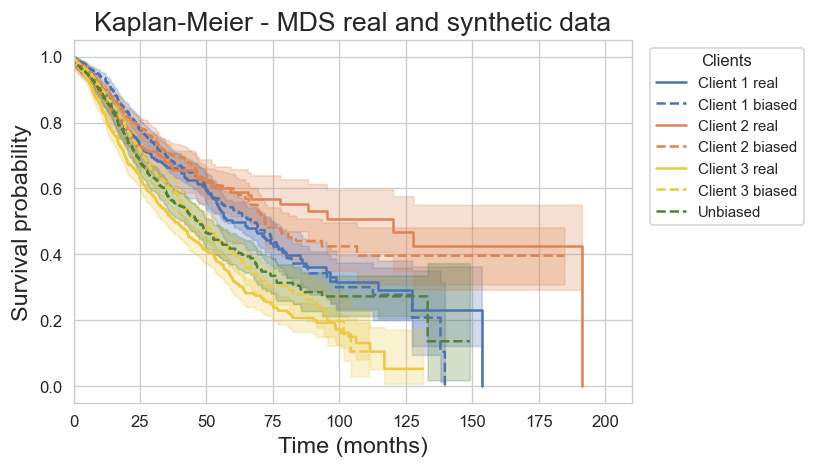

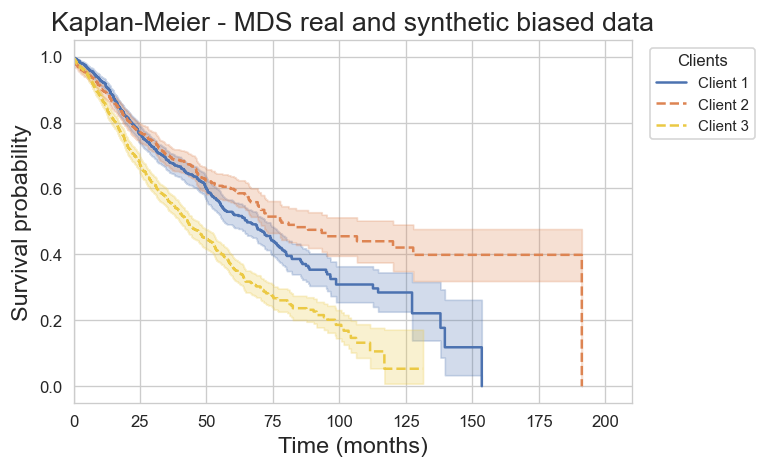

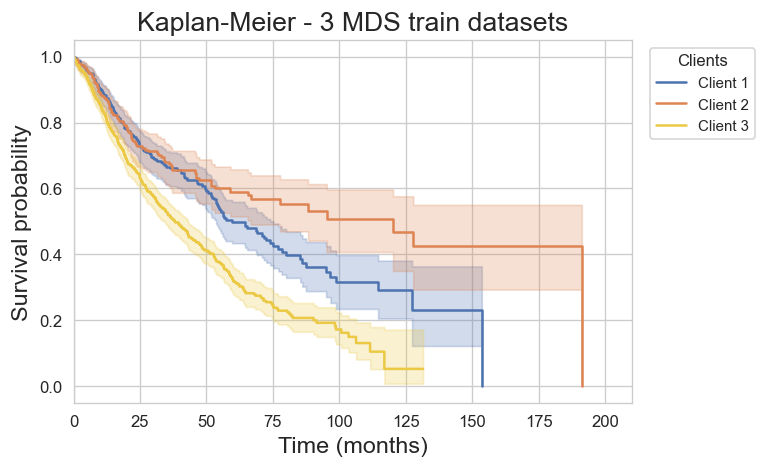

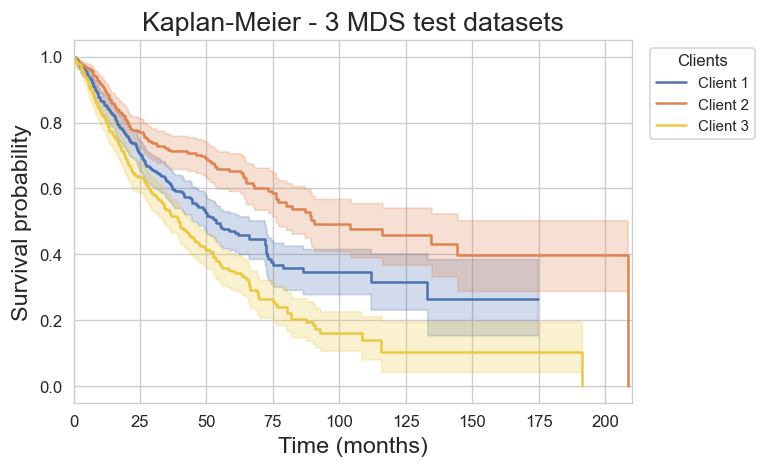

In [270]:
## MDS

kmf1 = KaplanMeierFitter()
kmf1.fit(durations=r1['time'], event_observed=r1['event']),
kmf2 = KaplanMeierFitter()
kmf2.fit(durations=G['time'], event_observed=G['event']),
kmf3 = KaplanMeierFitter()
kmf3.fit(durations=S1['time'], event_observed=S1['event']),

# Passo 2: Adatta il modello Kaplan-Meier
kmf4 = KaplanMeierFitter()
kmf4.fit(durations=r2['time'], event_observed=r2['event']),
kmf5 = KaplanMeierFitter()
kmf5.fit(durations=G['time'], event_observed=G['event']),
kmf6 = KaplanMeierFitter()
kmf6.fit(durations=S2['time'], event_observed=S2['event']),


# Passo 2: Adatta il modello Kaplan-Meier
kmf7 = KaplanMeierFitter()
kmf7.fit(durations=r3['time'], event_observed=r3['event']),
kmf8 = KaplanMeierFitter()
kmf8.fit(durations=G['time'], event_observed=G['event']),
kmf9 = KaplanMeierFitter()
kmf9.fit(durations=S3['time'], event_observed=S3['event']),


# PLOT KM CURVES ALL

colors = sns.color_palette("Set1", n_colors=7)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata
PALETTE = {
    "node-1": "#4C72B0",   # blu
    "node-2": "#DD8452",   # arancione
    "node-3": "#EBC944",   # giallo
    "unbiased": "#548235", # verde
}
colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1 real', color = colors[0])
kmf3.plot_survival_function(title='KM curves - 3 clients', label='Client 1 biased', color = colors[2],linestyle="--")
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2 real', color = colors[3])
kmf6.plot_survival_function(title='KM curves - 3 clients', label='Client 2 biased', color = colors[4],linestyle="--")
kmf7.plot_survival_function(title='KM curves - 3 clients', label='Client 3 real', color = colors[5])
kmf9.plot_survival_function(title='KM curves - 3 clients', label='Client 3 biased', color = colors[6],linestyle="--")
kmf2.plot_survival_function(title='KM curves - 3 clients', label='Unbiased', color = colors[1],linestyle="--")
#plt.grid()
plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - MDS real and synthetic data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkm_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

# PLOT KM CURVES ALL

a1 = pd.concat((r1, S1))
a2 = pd.concat((r2, S2))
a3 = pd.concat((r3, S3))

kmf11 = KaplanMeierFitter()
kmf11.fit(durations=a1['time'], event_observed=a1['event']),
kmf22 = KaplanMeierFitter()
kmf22.fit(durations=a2['time'], event_observed=a2['event']),
kmf33 = KaplanMeierFitter()
kmf33.fit(durations=a3['time'], event_observed=a3['event']),


sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata

colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf11.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf22.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3],linestyle="--")
kmf33.plot_survival_function(title='KM curves - 3 clients', label='Client 3', color = colors[5],linestyle="--")

#plt.grid()
plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - MDS real and synthetic biased data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkmbiased_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TRAINING

kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])
kmf7.plot_survival_function(title='KM curves - 3 clients', label='Client 3', color = colors[5])

#plt.grid()
plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 3 MDS train datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtrain_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TEST

kmft1 = KaplanMeierFitter()
kmft1.fit(durations=t1['time'], event_observed=t1['event']),
kmft2 = KaplanMeierFitter()
kmft2.fit(durations=t2['time'], event_observed=t2['event']),
kmft3 = KaplanMeierFitter()
kmft3.fit(durations=t3['time'], event_observed=t3['event']),

# Passo 3: Traccia la curva di Kaplan-Meier
kmft1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmft2.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])
kmft3.plot_survival_function(title='KM curves - 3 clients', label='Client 3', color = colors[5])

#plt.grid()
plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 3 MDS test datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtest_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

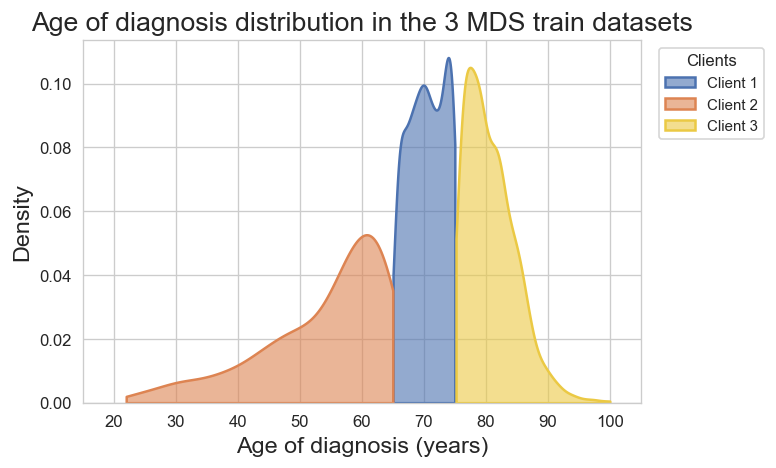

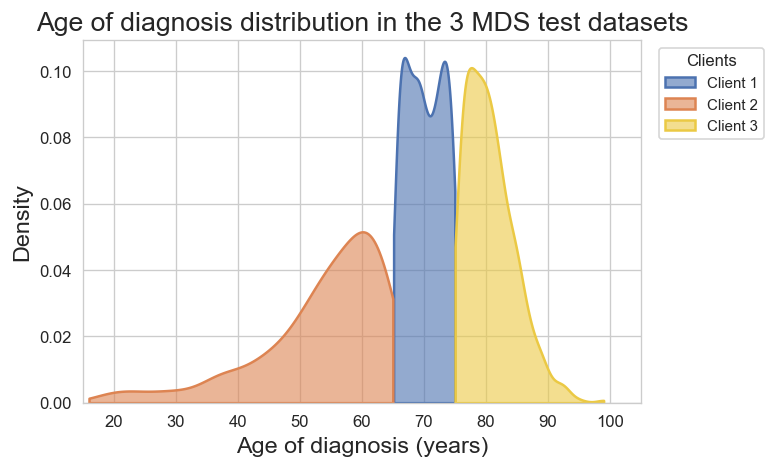

In [288]:
sns.kdeplot(
        r1['AOD'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r1['AOD']), max(r1['AOD'])),
        label='Client 1',
    )
sns.kdeplot(
        r2['AOD'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r2['AOD']), max(r2['AOD'])),
        label='Client 2',
    )
sns.kdeplot(
        r3['AOD'],
        color=colors[5],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r3['AOD']), max(r3['AOD'])),
        label='Client 3',
    )
plt.title("Age of diagnosis distribution in the 3 MDS train datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtrain_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

sns.kdeplot(
        t1['AOD'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t1['AOD']), max(t1['AOD'])),
        label='Client 1',
    )
sns.kdeplot(
        t2['AOD'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t2['AOD']), max(t2['AOD'])),
        label='Client 2',
    )
sns.kdeplot(
        t3['AOD'],
        color=colors[5],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t3['AOD']), max(t3['AOD'])),
        label='Client 3',
    )
plt.title("Age of diagnosis distribution in the 3 MDS test datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtest_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

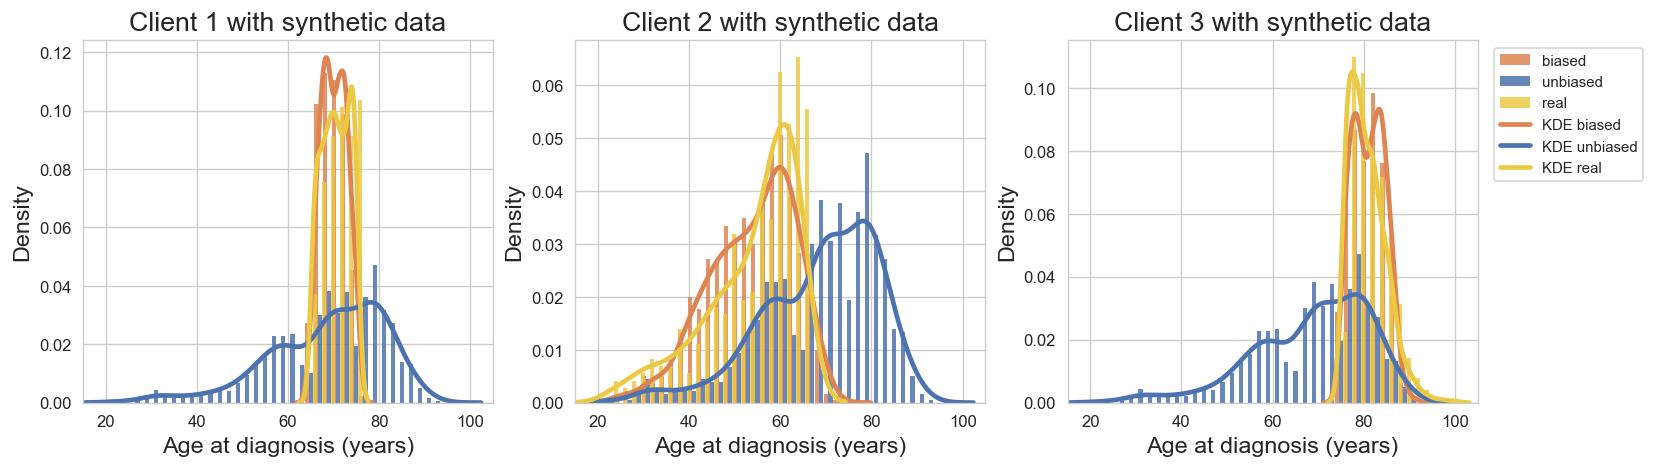

In [272]:
data = {
    "node-1": {
        "real":     r1['AOD'],
        "biased":   S1['AOD'],
        "unbiased": G['AOD'],
    },
    "node-2": {
        "real":     r2['AOD'],
        "biased":   S2['AOD'],
        "unbiased": G['AOD'],
    },
    "node-3": {
        "real":     r3['AOD'],
        "biased":   S3['AOD'],
        "unbiased": G['AOD'],
    },
}

PALETTE = {
    "biased": "#DD8452",    # arancione
    "unbiased": "#4C72B0",  # blu
    "real": "#EBC944",      # giallo
}
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------
nodes = ["node-1", "node-2", "node-3"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
bins = np.linspace(20, 100, 41)
bin_centers = (bins[:-1] + bins[1:]) / 2  # Centri dei bin
bin_width = (bins[1] - bins[0])*1.8            # Larghezza di ogni bin

# Larghezza delle barre (regola lo spazio tra i gruppi)
bar_width = bin_width * 0.25
 
for ax, node in zip(axes, nodes):
    # Calcola gli istogrammi per ogni tipo
    hist_data = {}
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        hist_data[kind], _ = np.histogram(values, bins=bins, density=True)

    # Plotta le barre affiancate (offset per ogni tipo)
    for i, kind in enumerate(["biased", "unbiased", "real"]):
        offset = (i - 1) * bar_width  # -bar_width, 0, +bar_width
        ax.bar(
            bin_centers + offset,
            hist_data[kind],
            width=bar_width,
            color=PALETTE[kind],
            label=kind,
            edgecolor="none",
            alpha=0.85
        )

    # KDE sovrapposte (invariate)
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        sns.kdeplot(values, ax=ax, color=PALETTE[kind], linewidth=2.8, label=f"KDE {kind}")
 
    ax.set_title(f"Client {node.split('-')[1]} with synthetic data", fontsize=16)
    ax.set_xlabel("Age at diagnosis (years)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_xlim(15, 105)
 
    # legenda solo con le voci utili, senza duplicati
    handles, labels = ax.get_legend_handles_labels()
    order_labels = ["biased", "unbiased", "real", "KDE biased", "KDE unbiased", "KDE real"]
    ordered = [(h, l) for l in order_labels for h, ll in zip(handles, labels) if ll == l]
    if node == 'node-3':
        ax.legend(
            [h for h, l in ordered], [l for h, l in ordered],
            bbox_to_anchor=(1.02, 1), loc="upper left",  fontsize=9, #frameon=False,
        )
#plt.subplots_adjust(wspace=0.3)
#fig.tight_layout()
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/data_density_distribution_mds_review.png', bbox_inches='tight', dpi=600)
plt.show()

In [290]:
# BRCA

features = ['Gender', 'AOD', 'Neutrophils', 'Hemoglobin', 'Platelets', 'BMB',
            'ASXL1', 'BCOR', 'BCORL1', 'CBL', 'CEBPA', 'DNMT3A', 'ETV6', 'EZH2',
            'FLT3', 'GATA2', 'GNAS', 'IDH1', 'IDH2', 'JAK2', 'KIT', 'KRAS', 'MPL',
            'NPM1', 'NRAS', 'PTPN11', 'RUNX1', 'SF3B1', 'SRSF2', 'STAG2', 'TET2',
            'TP53', 'U2AF1', 'WT1', 'ZRSR2', 'SETBP1', 'time', 'event']

cols_standardize = ['AOD', 'Neutrophils', 'Hemoglobin', 'Platelets', 'BMB']


g1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/BRCA/SYNTH_UNBIASED.csv").sample(n=200,random_state=42).reset_index(drop=True)
g2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/BRCA/SYNTH_UNBIASED.csv").sample(n=200,random_state=42).reset_index(drop=True)


S1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/BRCA/SYNTH_BIASED.csv").sample(n=200,random_state=41).reset_index(drop=True)
S2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/BRCA/SYNTH_BIASED.csv").sample(n=200,random_state=41).reset_index(drop=True)
r1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/BRCA/brca_.csv")
r2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/BRCA/brca_.csv")
t1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/BRCA/testbrca_.csv")
t2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/BRCA/testbrca_.csv")


G = pd.concat((g1, g2), axis=0)

d11 = pd.DataFrame({'time': r1['time'], 'event': r1['event'], 'group': np.full(len(r1), '1')})
d12 = pd.DataFrame({'time': G['time'], 'event': G['event'], 'group': np.full(len(G), '2')})

data = pd.concat((d11, d12))

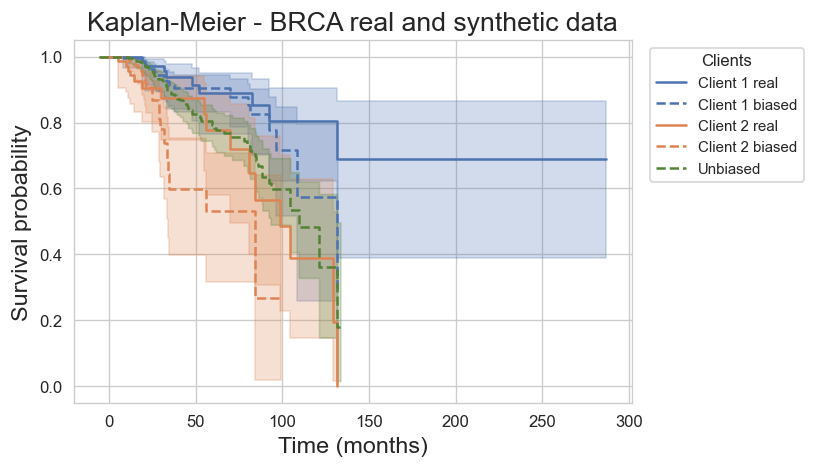

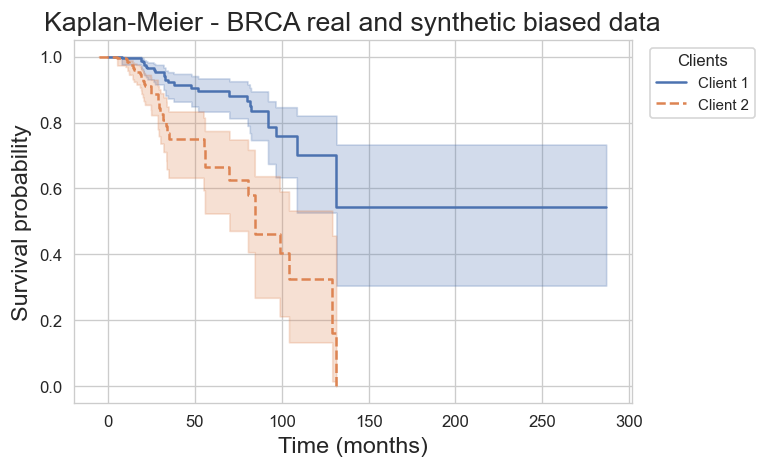

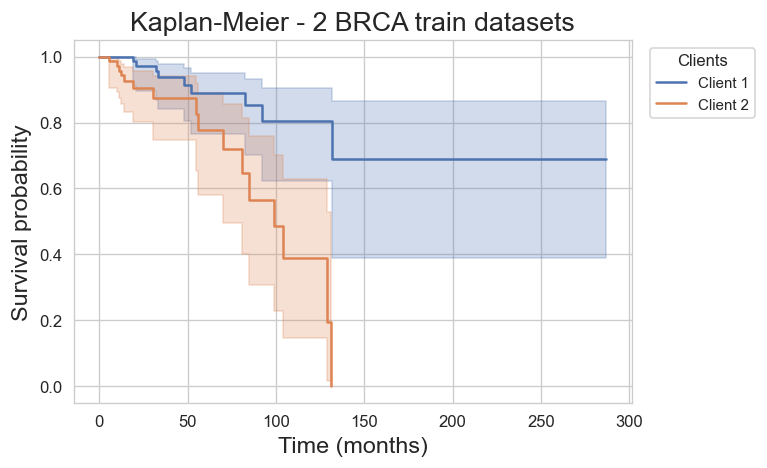

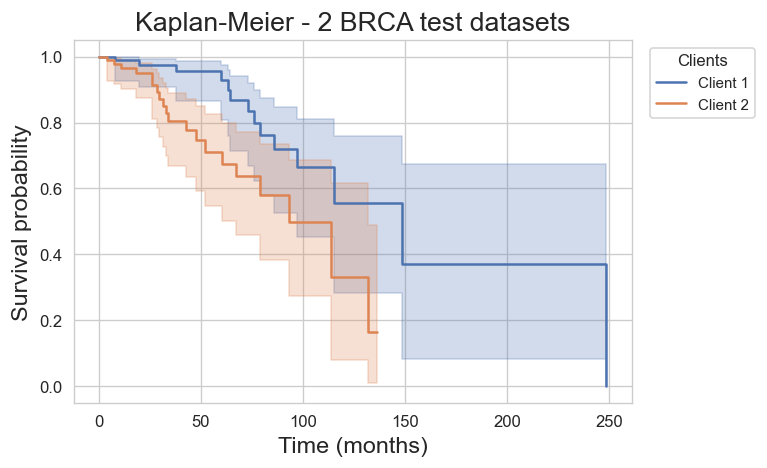

In [283]:
## MDS

r1['time'] = r1['time']/30
r2['time'] = r2['time']/30
S1['time'] = S1['time']/30
S2['time'] = S2['time']/30
G['time'] = G['time']/30
t1['time'] = t1['time']/30
t2['time'] = t2['time']/30

kmf1 = KaplanMeierFitter()
kmf1.fit(durations=r1['time'], event_observed=r1['event']),
kmf2 = KaplanMeierFitter()
kmf2.fit(durations=G['time'], event_observed=G['event']),
kmf3 = KaplanMeierFitter()
kmf3.fit(durations=S1['time'], event_observed=S1['event']),

# Passo 2: Adatta il modello Kaplan-Meier
kmf4 = KaplanMeierFitter()
kmf4.fit(durations=r2['time'], event_observed=r2['event']),
kmf5 = KaplanMeierFitter()
kmf5.fit(durations=G['time'], event_observed=G['event']),
kmf6 = KaplanMeierFitter()
kmf6.fit(durations=S2['time'], event_observed=S2['event']),



# PLOT KM CURVES ALL

colors = sns.color_palette("Set1", n_colors=7)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata
PALETTE = {
    "node-1": "#4C72B0",   # blu
    "node-2": "#DD8452",   # arancione
    "node-3": "#EBC944",   # giallo
    "unbiased": "#548235", # verde
}
colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1 real', color = colors[0])
kmf3.plot_survival_function(title='KM curves - 3 clients', label='Client 1 biased', color = colors[2],linestyle="--")
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2 real', color = colors[3])
kmf6.plot_survival_function(title='KM curves - 3 clients', label='Client 2 biased', color = colors[4],linestyle="--")
kmf2.plot_survival_function(title='KM curves - 3 clients', label='Unbiased', color = colors[1],linestyle="--")
#plt.grid()
#plt.xlim(0, max(r1['time'],r2['time'])+5)

plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - BRCA real and synthetic data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkm_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

# PLOT KM CURVES ALL

a1 = pd.concat((r1, S1))
a2 = pd.concat((r2, S2))

kmf11 = KaplanMeierFitter()
kmf11.fit(durations=a1['time'], event_observed=a1['event']),
kmf22 = KaplanMeierFitter()
kmf22.fit(durations=a2['time'], event_observed=a2['event']),



sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata

colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf11.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf22.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3],linestyle="--")

#plt.grid()
#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - BRCA real and synthetic biased data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkmbiased_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TRAINING

kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])

#plt.grid()

#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 2 BRCA train datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtrain_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TEST

kmft1 = KaplanMeierFitter()
kmft1.fit(durations=t1['time'], event_observed=t1['event']),
kmft2 = KaplanMeierFitter()
kmft2.fit(durations=t2['time'], event_observed=t2['event']),

# Passo 3: Traccia la curva di Kaplan-Meier
kmft1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmft2.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])


#plt.grid()
#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 2 BRCA test datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtest_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

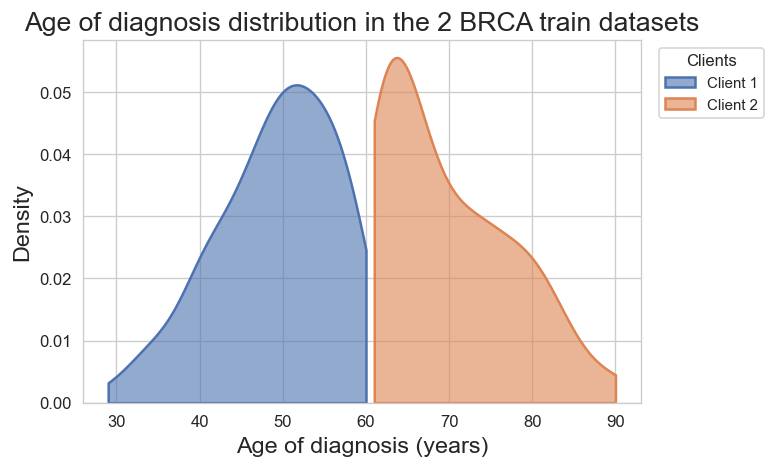

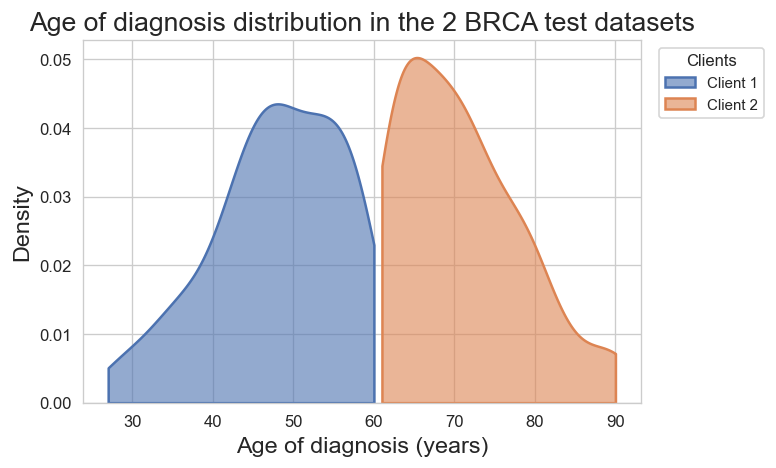

In [291]:
sns.kdeplot(
        r1['age_at_index'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r1['age_at_index']), max(r1['age_at_index'])),
        label='Client 1',
    )
sns.kdeplot(
        r2['age_at_index'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r2['age_at_index']), max(r2['age_at_index'])),
        label='Client 2',
    )

plt.title("Age of diagnosis distribution in the 2 BRCA train datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
#plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
#fig.savefig("age_distribution_3_datasets.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtrain_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

sns.kdeplot(
        t1['age_at_index'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t1['age_at_index']), max(t1['age_at_index'])),
        label='Client 1',
    )
sns.kdeplot(
        t2['age_at_index'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t2['age_at_index']), max(t2['age_at_index'])),
        label='Client 2',
    )

plt.title("Age of diagnosis distribution in the 2 BRCA test datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
#plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
#fig.savefig("age_distribution_3_datasets.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtest_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

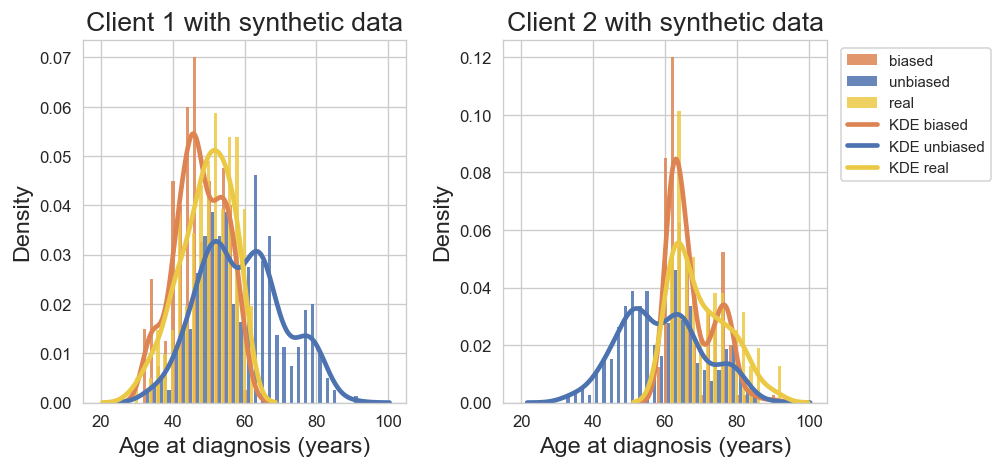

In [285]:
data = {
    "node-1": {
        "real":     r1['age_at_index'],
        "biased":   S1['age_at_index'],
        "unbiased": G['age_at_index'],
    },
    "node-2": {
        "real":     r2['age_at_index'],
        "biased":   S2['age_at_index'],
        "unbiased": G['age_at_index'],
    },
}

PALETTE = {
    "biased": "#DD8452",    # arancione
    "unbiased": "#4C72B0",  # blu
    "real": "#EBC944",      # giallo
}
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------
nodes = ["node-1", "node-2"]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
 
bins = np.linspace(20, 100, 41)
bin_centers = (bins[:-1] + bins[1:]) / 2  # Centri dei bin
bin_width = (bins[1] - bins[0])*1.8            # Larghezza di ogni bin

# Larghezza delle barre (regola lo spazio tra i gruppi)
bar_width = bin_width * 0.25
 
for ax, node in zip(axes, nodes):
    # Calcola gli istogrammi per ogni tipo
    hist_data = {}
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        hist_data[kind], _ = np.histogram(values, bins=bins, density=True)

    # Plotta le barre affiancate (offset per ogni tipo)
    for i, kind in enumerate(["biased", "unbiased", "real"]):
        offset = (i - 1) * bar_width  # -bar_width, 0, +bar_width
        ax.bar(
            bin_centers + offset,
            hist_data[kind],
            width=bar_width,
            color=PALETTE[kind],
            label=kind,
            edgecolor="none",
            alpha=0.85
        )

    # KDE sovrapposte (invariate)
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        sns.kdeplot(values, ax=ax, color=PALETTE[kind], linewidth=2.8, label=f"KDE {kind}")
 
    ax.set_title(f"Client {node.split('-')[1]} with synthetic data", fontsize=16)
    ax.set_xlabel("Age at diagnosis (years)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_xlim(15, 105)
 
    # legenda solo con le voci utili, senza duplicati
    handles, labels = ax.get_legend_handles_labels()
    order_labels = ["biased", "unbiased", "real", "KDE biased", "KDE unbiased", "KDE real"]
    ordered = [(h, l) for l in order_labels for h, ll in zip(handles, labels) if ll == l]
    if node == 'node-2':
        ax.legend(
            [h for h, l in ordered], [l for h, l in ordered],
            bbox_to_anchor=(1.02, 1), loc="upper left",  fontsize=9, #frameon=False,
        )
plt.subplots_adjust(wspace=0.3) 
#fig.tight_layout()
#fig.savefig("age_density_per_node.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/data_density_distribution_brca_review.png', bbox_inches='tight', dpi=600)
plt.show()

In [292]:
# LGG



g1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/LGG/SYNTH_UNBIASED.csv").sample(n=600,random_state=41).reset_index(drop=True)
g2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/LGG/SYNTH_UNBIASED.csv").sample(n=40,random_state=41).reset_index(drop=True)


S1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/LGG/SYNTH_BIASED.csv").sample(n=600,random_state=44).reset_index(drop=True)
S2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/LGG/SYNTH_BIASED.csv").sample(n=40,random_state=41).reset_index(drop=True)
r1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/LGG/lgg_.csv")
r2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/LGG/lgg_.csv")
t1 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node1/LGG/testlgg_.csv")
t2 = pd.read_csv("C:/Users/Lenovo/Desktop/FedSDS_biased_flower/Node2/LGG/testlgg_.csv")


G = pd.concat((g1, g2), axis=0)

d11 = pd.DataFrame({'time': r1['time'], 'event': r1['event'], 'group': np.full(len(r1), '1')})
d12 = pd.DataFrame({'time': G['time'], 'event': G['event'], 'group': np.full(len(G), '2')})

data = pd.concat((d11, d12))

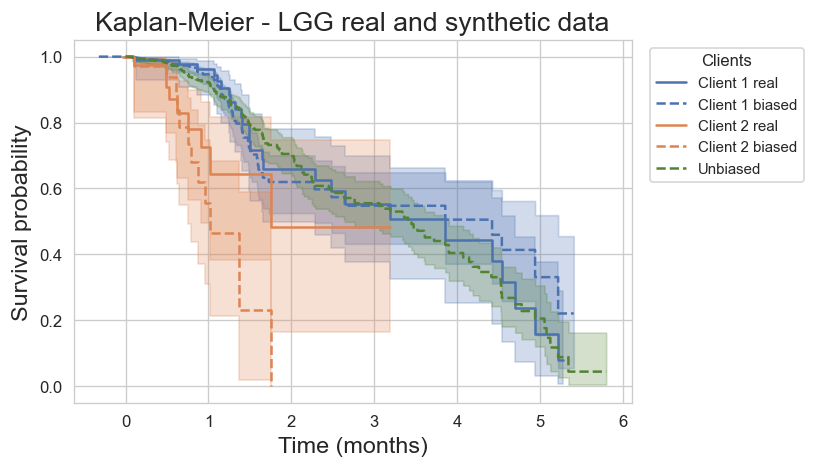

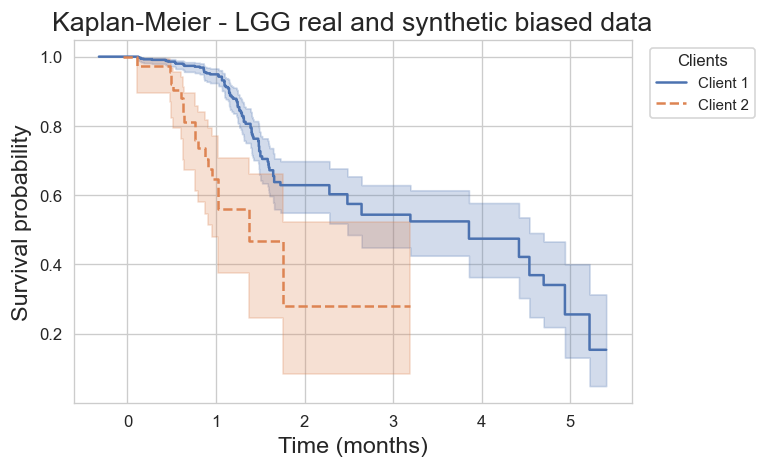

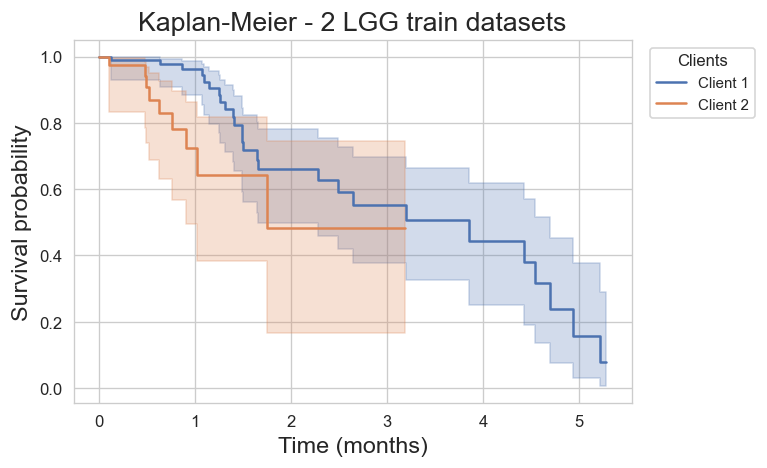

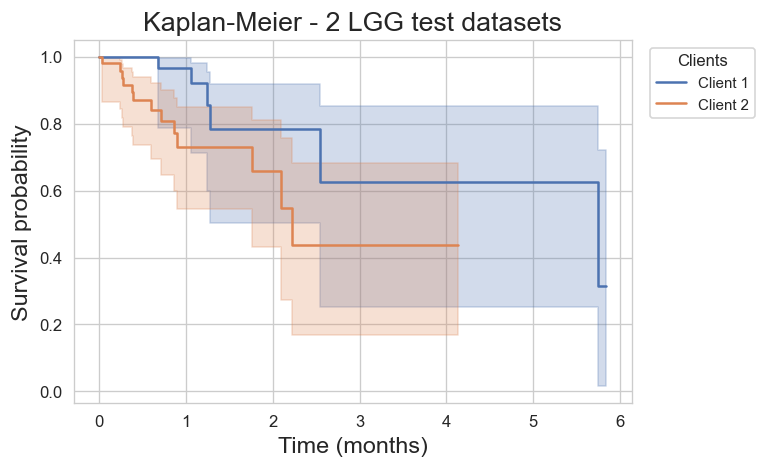

In [280]:
## MDS

r1['time'] = r1['time']/30
r2['time'] = r2['time']/30
S1['time'] = S1['time']/30
S2['time'] = S2['time']/30
G['time'] = G['time']/30
t1['time'] = t1['time']/30
t2['time'] = t2['time']/30

kmf1 = KaplanMeierFitter()
kmf1.fit(durations=r1['time'], event_observed=r1['event']),
kmf2 = KaplanMeierFitter()
kmf2.fit(durations=G['time'], event_observed=G['event']),
kmf3 = KaplanMeierFitter()
kmf3.fit(durations=S1['time'], event_observed=S1['event']),

# Passo 2: Adatta il modello Kaplan-Meier
kmf4 = KaplanMeierFitter()
kmf4.fit(durations=r2['time'], event_observed=r2['event']),
kmf5 = KaplanMeierFitter()
kmf5.fit(durations=G['time'], event_observed=G['event']),
kmf6 = KaplanMeierFitter()
kmf6.fit(durations=S2['time'], event_observed=S2['event']),



# PLOT KM CURVES ALL

colors = sns.color_palette("Set1", n_colors=7)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata
PALETTE = {
    "node-1": "#4C72B0",   # blu
    "node-2": "#DD8452",   # arancione
    "node-3": "#EBC944",   # giallo
    "unbiased": "#548235", # verde
}
colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1 real', color = colors[0])
kmf3.plot_survival_function(title='KM curves - 3 clients', label='Client 1 biased', color = colors[2],linestyle="--")
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2 real', color = colors[3])
kmf6.plot_survival_function(title='KM curves - 3 clients', label='Client 2 biased', color = colors[4],linestyle="--")
kmf2.plot_survival_function(title='KM curves - 3 clients', label='Unbiased', color = colors[1],linestyle="--")
#plt.grid()
#plt.xlim(0, max(r1['time'],r2['time'])+5)

plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - LGG real and synthetic data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkm_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

# PLOT KM CURVES ALL

a1 = pd.concat((r1, S1))
a2 = pd.concat((r2, S2))

kmf11 = KaplanMeierFitter()
kmf11.fit(durations=a1['time'], event_observed=a1['event']),
kmf22 = KaplanMeierFitter()
kmf22.fit(durations=a2['time'], event_observed=a2['event']),



sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
 
# Palette coerente con l'immagine: blu (node-1), arancione (node-2),
# giallo (node-3), verde per la curva "unbiased" aggregata

colors = ["#4C72B0", "#548235", "#4C72B0","#DD8452","#DD8452","#EBC944","#EBC944"]

# Passo 3: Traccia la curva di Kaplan-Meier
kmf11.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf22.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3],linestyle="--")

#plt.grid()
#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - LGG real and synthetic biased data", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/allkmbiased_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TRAINING

kmf1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmf4.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])

#plt.grid()

#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 2 LGG train datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtrain_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

### TEST

kmft1 = KaplanMeierFitter()
kmft1.fit(durations=t1['time'], event_observed=t1['event']),
kmft2 = KaplanMeierFitter()
kmft2.fit(durations=t2['time'], event_observed=t2['event']),

# Passo 3: Traccia la curva di Kaplan-Meier
kmft1.plot_survival_function(title='KM curves - 3 clients', label='Client 1', color = colors[0])
kmft2.plot_survival_function(title='KM curves - 3 clients', label='Client 2', color = colors[3])


#plt.grid()
#plt.xlim(0, 210)
plt.xlabel('Time (months)', fontsize=14)
plt.ylabel('Survival probability', fontsize=14)
plt.title("Kaplan-Meier - 2 LGG test datasets", fontsize=16)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
#plt.savefig('./../FL/Results/km_curves_all.svg', bbox_inches='tight')
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/kmtest_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

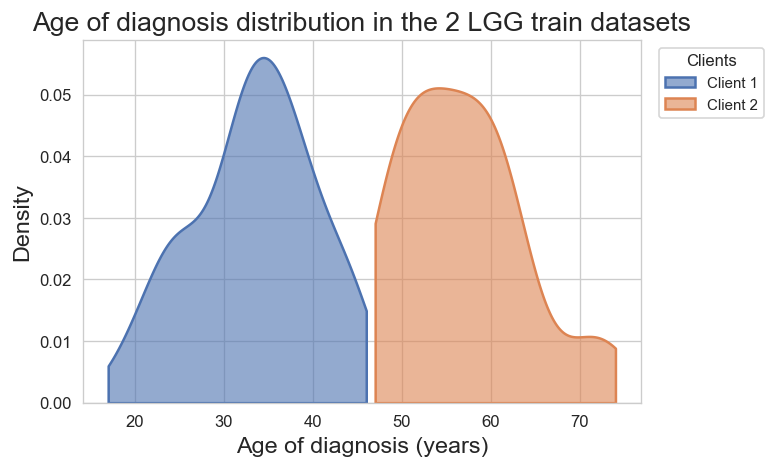

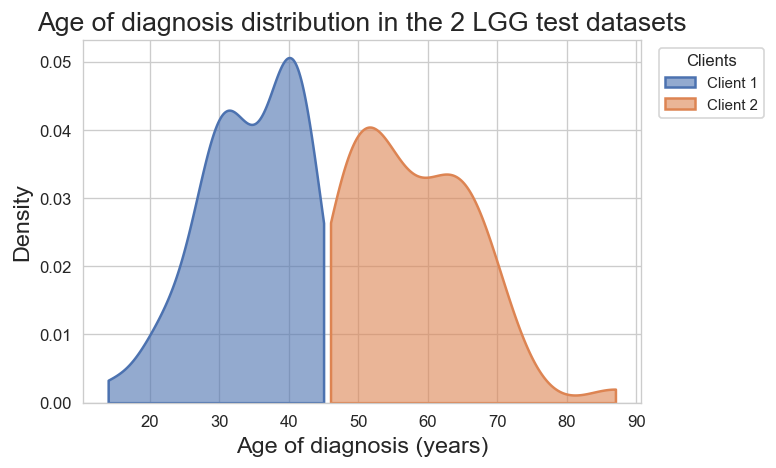

In [293]:
sns.kdeplot(
        r1['age_at_index'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r1['age_at_index']), max(r1['age_at_index'])),
        label='Client 1',
    )
sns.kdeplot(
        r2['age_at_index'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(r2['age_at_index']), max(r2['age_at_index'])),
        label='Client 2',
    )

plt.title("Age of diagnosis distribution in the 2 LGG train datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
#plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
#fig.savefig("age_distribution_3_datasets.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtrain_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

sns.kdeplot(
        t1['age_at_index'],
        color=colors[0],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t1['age_at_index']), max(t1['age_at_index'])),
        label='Client 1',
    )
sns.kdeplot(
        t2['age_at_index'],
        color=colors[3],
        fill=True,
        alpha=0.6,
        linewidth=1.5,
        clip=(min(t2['age_at_index']), max(t2['age_at_index'])),
        label='Client 2',
    )

plt.title("Age of diagnosis distribution in the 2 LGG test datasets", fontsize=16)
plt.xlabel("Age of diagnosis (years)", fontsize=14)
plt.ylabel("Density", fontsize=14)
#plt.xlim(15, 105)
plt.legend(
    title="Clients",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    #frameon=False,
    fontsize=9,
    title_fontsize=10,
)
 
#fig.tight_layout()
#fig.savefig("age_distribution_3_datasets.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/aodtest_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()

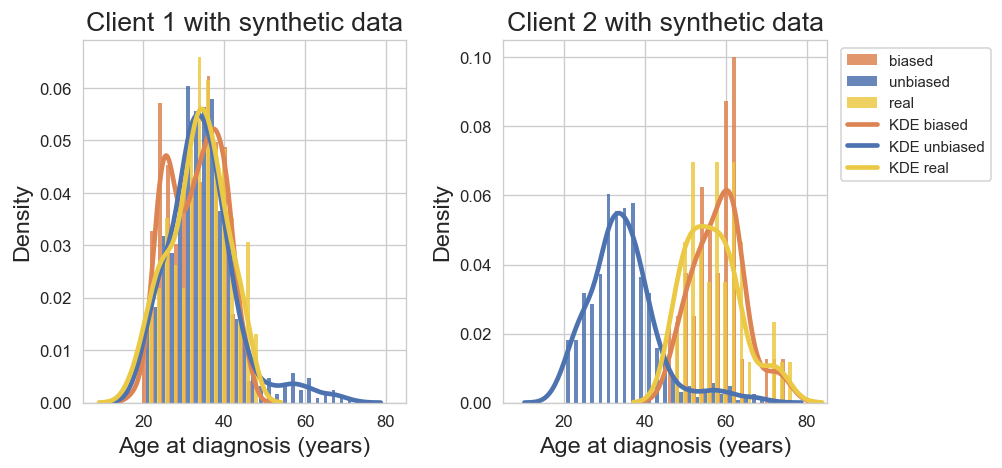

In [279]:
data = {
    "node-1": {
        "real":     r1['age_at_index'],
        "biased":   S1['age_at_index'],
        "unbiased": G['age_at_index'],
    },
    "node-2": {
        "real":     r2['age_at_index'],
        "biased":   S2['age_at_index'],
        "unbiased": G['age_at_index'],
    },
}

PALETTE = {
    "biased": "#DD8452",    # arancione
    "unbiased": "#4C72B0",  # blu
    "real": "#EBC944",      # giallo
}
# ----------------------------------------------------------------------
# PLOT
# ----------------------------------------------------------------------
nodes = ["node-1", "node-2"]
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
 
bins = np.linspace(20, 100, 41)
bin_centers = (bins[:-1] + bins[1:]) / 2  # Centri dei bin
bin_width = (bins[1] - bins[0])*1.8            # Larghezza di ogni bin

# Larghezza delle barre (regola lo spazio tra i gruppi)
bar_width = bin_width * 0.25
 
for ax, node in zip(axes, nodes):
    # Calcola gli istogrammi per ogni tipo
    hist_data = {}
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        hist_data[kind], _ = np.histogram(values, bins=bins, density=True)

    # Plotta le barre affiancate (offset per ogni tipo)
    for i, kind in enumerate(["biased", "unbiased", "real"]):
        offset = (i - 1) * bar_width  # -bar_width, 0, +bar_width
        ax.bar(
            bin_centers + offset,
            hist_data[kind],
            width=bar_width,
            color=PALETTE[kind],
            label=kind,
            edgecolor="none",
            alpha=0.85
        )

    # KDE sovrapposte (invariate)
    for kind in ["biased", "unbiased", "real"]:
        values = data[node][kind]
        sns.kdeplot(values, ax=ax, color=PALETTE[kind], linewidth=2.8, label=f"KDE {kind}")
 
    ax.set_title(f"Client {node.split('-')[1]} with synthetic data", fontsize=16)
    ax.set_xlabel("Age at diagnosis (years)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_xlim(5, 85)
 
    # legenda solo con le voci utili, senza duplicati
    handles, labels = ax.get_legend_handles_labels()
    order_labels = ["biased", "unbiased", "real", "KDE biased", "KDE unbiased", "KDE real"]
    ordered = [(h, l) for l in order_labels for h, ll in zip(handles, labels) if ll == l]
    if node == 'node-2':
        ax.legend(
            [h for h, l in ordered], [l for h, l in ordered],
            bbox_to_anchor=(1.02, 1), loc="upper left",  fontsize=9, #frameon=False,
        )
plt.subplots_adjust(wspace=0.3)
#fig.tight_layout()
#fig.savefig("age_density_per_node.png", dpi=200, bbox_inches="tight")
plt.savefig('C:/Users/Lenovo/Desktop/FedSDS_review/data_density_distribution_lgg_review.png', bbox_inches='tight', dpi=600)
plt.show()